## Practice Lecture 18 - Training DNN
In this lab we will look at how to train Deep Neural Networks for classification and regression. \
Based on Chapter 11 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice18_trainingDNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


## Exercise 1: activation functions
Plot activation functions logit, relu and leaky-relu

In [2]:
z=np.arange(-5,5,0.1)

In [3]:
def logit(z):
    return 1 / (1 + np.exp(-z))

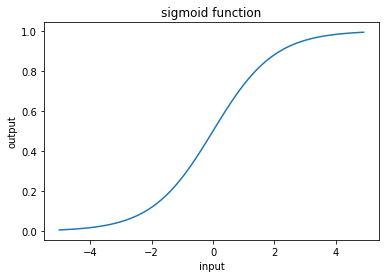

In [4]:
plt.figure()
plt.plot(z,logit(z))
plt.xlabel('input')
plt.ylabel('output')
plt.title('sigmoid function');

In [5]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

when Leaky Relu has coefficient $alpha=0$ it is the same as RELU

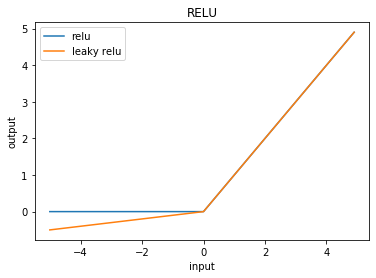

In [6]:
plt.plot(z,leaky_relu(z,0.0),label='relu')
plt.plot(z,leaky_relu(z,0.1),label='leaky relu')
plt.legend()
plt.xlabel('input')
plt.ylabel('output')
plt.title('RELU');

## Exercise 2: training for MNIST with different activation functions and initialization
Train a network for MNIST data using leaky_relu and compare with relu and sigmoid. Also compare two different initializations "he_init" and "zeros".\
For each case plot the loss and validations curves and evaluate on the test data.\
What does it work and what doesn't?

In [7]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

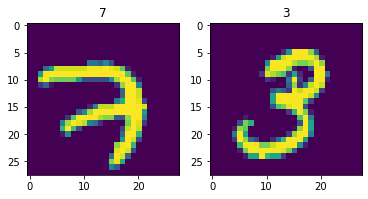

In [8]:
plt.figure()
plt.subplot(121);plt.imshow(X_train[0]);plt.title(y_train[0]);
plt.subplot(122);plt.imshow(X_train[1]);plt.title(y_train[1]);


In [9]:
dir(keras.initializers)

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_sys',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [10]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [11]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'tanh']

In [12]:
[m for m in dir(keras.layers) if "relu" in m.lower()]

['LeakyReLU', 'PReLU', 'ReLU', 'ThresholdedReLU']

In [13]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [14]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 300)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
__________________________________________________

In [16]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 70us/sample - loss: 1.4602 - accuracy: 0.6168 - val_loss: 0.8915 - val_accuracy: 0.8098
Epoch 2/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.7203 - accuracy: 0.8299 - val_loss: 0.5761 - val_accuracy: 0.8588
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.5348 - accuracy: 0.8615 - val_loss: 0.4656 - val_accuracy: 0.8794
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.4573 - accuracy: 0.8770 - val_loss: 0.4103 - val_accuracy: 0.8912
Epoch 5/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.4140 - accuracy: 0.8862 - val_loss: 0.3767 - val_accuracy: 0.8976
Epoch 6/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3859 - accuracy: 0.8924 - val_loss: 0.3537 - val_accuracy: 0.9030
Epoch 7/10
55000/55000 [==============================] -

In [17]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 39us/sample - loss: 0.3071 - accuracy: 0.9138


[0.3071155452668667, 0.9138]

In [18]:
history.params

{'batch_size': 32,
 'epochs': 10,
 'steps': 1719,
 'samples': 55000,
 'verbose': 0,
 'do_validation': True,
 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}

In [19]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

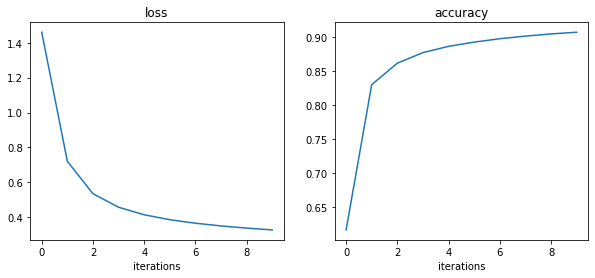

In [20]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(121);plt.plot(history.history["loss"])
    plt.xlabel('iterations')
    plt.title('loss')
    plt.subplot(122);plt.plot(history.history["accuracy"])
    plt.xlabel('iterations')
    plt.title('accuracy');
    
plot_history(history)

Let us compare with the standard RELU activation

In [21]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=[28,28]))
model2.add(keras.layers.Dense(300,activation="relu"))
model2.add(keras.layers.Dense(100,activation="relu"))
model2.add(keras.layers.Dense(10,activation="softmax"))

In [22]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [23]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [24]:
history2 = model2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 3s 63us/sample - loss: 1.7701 - accuracy: 0.5409 - val_loss: 1.1946 - val_accuracy: 0.7752
Epoch 2/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.8949 - accuracy: 0.8077 - val_loss: 0.6774 - val_accuracy: 0.8430
Epoch 3/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.6008 - accuracy: 0.8542 - val_loss: 0.5139 - val_accuracy: 0.8734
Epoch 4/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.4887 - accuracy: 0.8751 - val_loss: 0.4357 - val_accuracy: 0.8890
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.4290 - accuracy: 0.8867 - val_loss: 0.3901 - val_accuracy: 0.8968
Epoch 6/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.3914 - accuracy: 0.8947 - val_loss: 0.3590 - val_accuracy: 0.9050
Epoch 7/10
55000/55000 [==============================] -

In [25]:
model2.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 38us/sample - loss: 0.2948 - accuracy: 0.9180


[0.29483982368707656, 0.918]

In [26]:
print(history.params)
print(history2.params)

{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}
{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}


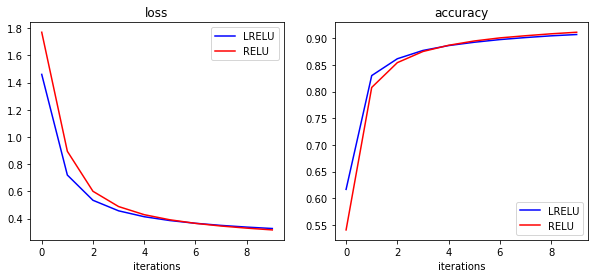

In [27]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history,history2,'LRELU','RELU')

We can see different activation functions implemented in Keras using dir(keras.activations)

In [28]:
model3 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [29]:
history3 = model3.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))


Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 2.3055 - accuracy: 0.1375 - val_loss: 2.2652 - val_accuracy: 0.1780
Epoch 2/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.2509 - accuracy: 0.2363 - val_loss: 2.2323 - val_accuracy: 0.3268
Epoch 3/10
55000/55000 [==============================] - 3s 59us/sample - loss: 2.2174 - accuracy: 0.3406 - val_loss: 2.1972 - val_accuracy: 0.4388
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.1809 - accuracy: 0.4262 - val_loss: 2.1588 - val_accuracy: 0.5192
Epoch 5/10
55000/55000 [==============================] - 3s 60us/sample - loss: 2.1403 - accuracy: 0.4951 - val_loss: 2.1145 - val_accuracy: 0.5166
Epoch 6/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.0943 - accuracy: 0.5342 - val_loss: 2.0649 - val_accuracy: 0.5458
Epoch 7/10
55000/55000 [==============================] -

In [30]:
model3.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 38us/sample - loss: 1.7959 - accuracy: 0.6453


[1.7959224107742309, 0.6453]

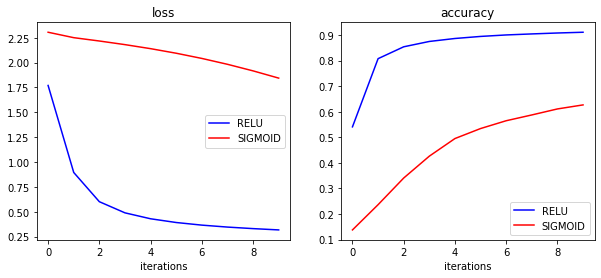

In [31]:
plot_history(history2,history3,'RELU','SIGMOID')

The same for initializers. We can check what is available by dir(keras.initializers)

In [32]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [33]:
model4 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history4 = model4.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model4.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 3s 62us/sample - loss: 2.3234 - accuracy: 0.1044 - val_loss: 2.3016 - val_accuracy: 0.1126
Epoch 2/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3009 - val_accuracy: 0.1126
Epoch 3/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3005 - val_accuracy: 0.1126
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3007 - val_accuracy: 0.1126
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.3013 - accuracy: 0.1123 - val_loss: 2.3008 - val_accuracy: 0.1126
Epoch 6/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.3012 - accuracy: 0.1124 - val_loss: 2.3008 - val_accuracy: 0.1126
Epoch 7/10
55000/55000 [==============================] -

[2.300515705871582, 0.1135]

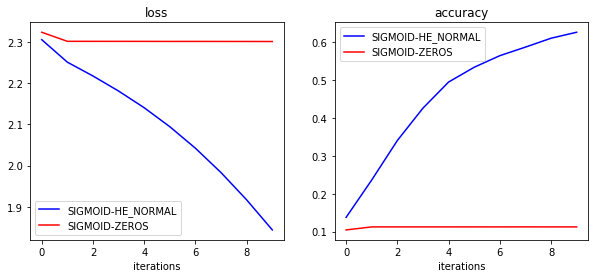

In [34]:
plot_history(history3,history4,'SIGMOID-HE_NORMAL','SIGMOID-ZEROS')

## Exercise 3: 
Use the first model with/without batch normalization. Plot the loss and accuracy curves for training and validation. Do you see any difference?
How many more parameters you need to optimize and why?

In [35]:
model5 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [36]:
model5.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense_12 (Dense)             (None, 300)               235500    
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 300)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 300)               1200      
_________________________________________________________________
dense_13 (Dense)             (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 100)              

In [37]:
model5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history5 = model5.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model5.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 6s 103us/sample - loss: 0.8904 - accuracy: 0.7270 - val_loss: 0.5091 - val_accuracy: 0.8510
Epoch 2/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.4877 - accuracy: 0.8587 - val_loss: 0.3901 - val_accuracy: 0.8906
Epoch 3/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.4132 - accuracy: 0.8796 - val_loss: 0.3401 - val_accuracy: 0.9046
Epoch 4/10
55000/55000 [==============================] - 5s 90us/sample - loss: 0.3713 - accuracy: 0.8919 - val_loss: 0.3111 - val_accuracy: 0.9132
Epoch 5/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.3472 - accuracy: 0.8991 - val_loss: 0.2886 - val_accuracy: 0.9192
Epoch 6/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.3243 - accuracy: 0.9051 - val_loss: 0.2734 - val_accuracy: 0.9240
Epoch 7/10
55000/55000 [==============================] 

[0.24239658519029617, 0.9297]

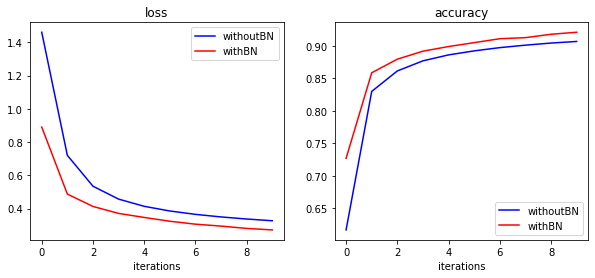

In [38]:
plot_history(history, history5, 'withoutBN','withBN')

## Exercise 4
Load the fashion_mnist model as shown below and train it to do multiclass classification as shown on the book's notebook.\
When training remove classes 8 and 9 to use them as a different dataset.\
Then take only these two classes and do binary classification on them.\
Instead of training the network from scratch, start from the network trained for the full data set. \
Replace the last layer for a sigmoid (softmax, i.e. multiclass, to sigmoid, binary classification). 

We take the full dataset first

In [39]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Now we split the data into two new data sets, A and B. \
A has 7 classes (all original classes without 8 and 9) and can be classified with multiclass methods.\
B has 2 classes (Bag is false, Ankle Boot is True.\
We will train on the model A and then use it for B.\
That is we will switch from multiclass to binary classification.

In [40]:
print(class_names[8:10])
def split_dataset(X, y):
    y_8_or_9 = (y == 8) | (y == 9) # bag or ankle boots
    y_A = y[~y_8_or_9]    
    y_B = (y[y_8_or_9] == 9).astype(np.float32) # binary classification task, 8 False, 9 True
    return ((X[~y_8_or_9], y_A),
            (X[y_8_or_9], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

['Bag', 'Ankle boot']


Let us check the indexes for model A and model B to make sure we did make mistakes.

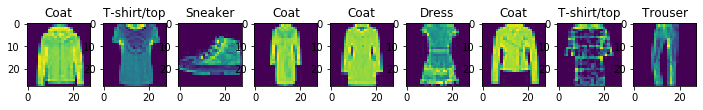

In [41]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_A[i]);plt.title(class_names[y_train_A[i]])

In [42]:
class_nameB=['bag','boot']

1.0
1.0
1.0
0.0
0.0
0.0
1.0
1.0
1.0


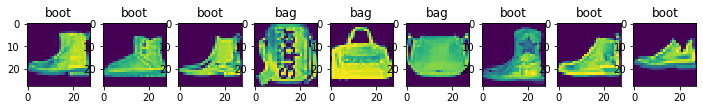

In [43]:
plt.figure(figsize=(12,6))
for i in range(9):
    print(y_train_B[i])
    plt.subplot(191+i)
    plt.imshow(X_train_B[i]);plt.title(class_nameB[np.int8(y_train_B[i])])

Now we start training model A. We build a sequential model as we did before.

In [44]:
tf.random.set_seed(42)
np.random.seed(42)

In [45]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

But we train it using the dataset A. We will train from scratch.

In [46]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(lr=1e-3),
                metrics=["accuracy"])
model_A.fit(X_train_A,y_train_A,validation_data=(X_valid_A,y_valid_A),epochs=10)

Train on 43996 samples, validate on 4004 samples
Epoch 1/10
43996/43996 [==============================] - 3s 75us/sample - loss: 0.7983 - accuracy: 0.7193 - val_loss: 0.5734 - val_accuracy: 0.7947
Epoch 2/10
43996/43996 [==============================] - 3s 64us/sample - loss: 0.5486 - accuracy: 0.8021 - val_loss: 0.5065 - val_accuracy: 0.8252
Epoch 3/10
43996/43996 [==============================] - 3s 64us/sample - loss: 0.5008 - accuracy: 0.8168 - val_loss: 0.4782 - val_accuracy: 0.8269
Epoch 4/10
43996/43996 [==============================] - 3s 64us/sample - loss: 0.4741 - accuracy: 0.8274 - val_loss: 0.4571 - val_accuracy: 0.8359
Epoch 5/10
43996/43996 [==============================] - 3s 64us/sample - loss: 0.4552 - accuracy: 0.8322 - val_loss: 0.4517 - val_accuracy: 0.8367
Epoch 6/10
43996/43996 [==============================] - 3s 64us/sample - loss: 0.4419 - accuracy: 0.8383 - val_loss: 0.4375 - val_accuracy: 0.8414
Epoch 7/10
43996/43996 [==============================] -

In [47]:
model_A.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_15 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_16 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_17 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_18 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_19 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_20 (Dense)             (None, 8)                

The main part of this exercise is to train for dataset B but starting from the model trained in dataset A.\
Notice that model A has never seeing a bag or ankle boot. Let use save the model first.

In [48]:
model_A.save("my_model_A.h5")

Now we will create a new model B by using layers from modelA except for the last one (the softmax with the softmax activation) since these layer was designed for multiclasses.\
We will replace this last layer with a simpler sigmoid (as usual for binary classification).

In [49]:
model_A = keras.models.load_model("my_model_A.h5")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

In [50]:
for i in np.arange(len(model_A.layers)): 
    print(model_A.layers[i].name,'\t',model_B_on_A.layers[i].name)

flatten_5 	 flatten_5
dense_15 	 dense_15
dense_16 	 dense_16
dense_17 	 dense_17
dense_18 	 dense_18
dense_19 	 dense_19
dense_20 	 dense_21


We need to fix the weights for all layers except the last one we want to change.

In [51]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])

In [52]:
model_B_on_A.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_15 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_16 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_17 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_18 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_19 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_21 (Dense)             (None, 1)                

Now let us evaluate the models in the datasets A and B.\
Since model_A was already training for dataset A, it produces a good result for testA

In [53]:
model_A.evaluate(X_test_A, y_test_A)

8000/8000 [==============================] - 0s 55us/sample - loss: 0.4573 - accuracy: 0.8317


[0.45726160484552386, 0.83175]

The last layer of model_B_on_A has not been trained yet for dataset B. The rest of the layers are good. Let us try it to see if the last layer is important.

In [54]:
model_B_on_A.evaluate(X_test_B, y_test_B)

2000/2000 [==============================] - 0s 104us/sample - loss: 1.4701 - accuracy: 0.3825


[1.4701394805908203, 0.3825]

Let us now train the last layer.

In [55]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/4
200/200 [==============================] - 0s 2ms/sample - loss: 1.4338 - accuracy: 0.3800 - val_loss: 1.4298 - val_accuracy: 0.3825
Epoch 2/4
200/200 [==============================] - 0s 391us/sample - loss: 1.3618 - accuracy: 0.3850 - val_loss: 1.3563 - val_accuracy: 0.3805
Epoch 3/4
200/200 [==============================] - 0s 361us/sample - loss: 1.2922 - accuracy: 0.3900 - val_loss: 1.2821 - val_accuracy: 0.3755
Epoch 4/4
2000/2000 [==============================] - 0s 44us/sample - loss: 1.1876 - accuracy: 0.3815


[1.1876496229171754, 0.3815]

In [56]:
y_prob_B = model_B_on_A.predict(X_test_B)

/home/dtrad/anaconda3/envs/tfgpu2/lib/python3.7/site-packages/matplotlib/text.py:1150: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


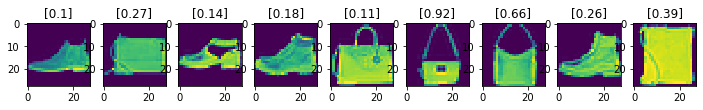

In [57]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(np.round(y_prob_B[i],2))

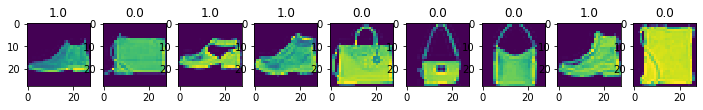

In [58]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title((y_test_B[i]))

It looks like we need to train a bit more than just the last layer. Let us make them all layers trainable.

In [59]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/16
200/200 [==============================] - 1s 3ms/sample - loss: 1.0367 - accuracy: 0.3800 - val_loss: 0.8778 - val_accuracy: 0.4177
Epoch 2/16
200/200 [==============================] - 0s 387us/sample - loss: 0.7596 - accuracy: 0.4900 - val_loss: 0.6680 - val_accuracy: 0.5914
Epoch 3/16
200/200 [==============================] - 0s 375us/sample - loss: 0.5764 - accuracy: 0.7050 - val_loss: 0.5272 - val_accuracy: 0.8032
Epoch 4/16
200/200 [==============================] - 0s 355us/sample - loss: 0.4550 - accuracy: 0.8500 - val_loss: 0.4385 - val_accuracy: 0.8705
Epoch 5/16
200/200 [==============================] - 0s 354us/sample - loss: 0.3753 - accuracy: 0.9200 - val_loss: 0.3685 - val_accuracy: 0.9267
Epoch 6/16
200/200 [==============================] - 0s 361us/sample - loss: 0.3161 - accuracy: 0.9700 - val_loss: 0.3252 - val_accuracy: 0.9418
Epoch 7/16
200/200 [==============================] - 0s 363us/sample - loss: 0.

[0.13491990625858308, 0.979]

It did a good job now, but did the original training help at all? 

In [60]:
y_prob_B = model_B_on_A.predict(X_test_B)

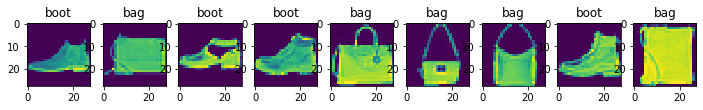

In [61]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);plt.title(class_nameB[np.int8(y_test_B[i])])

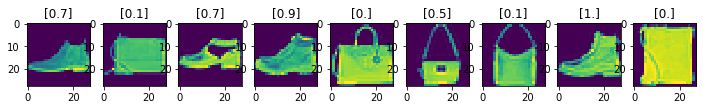

In [62]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    #plt.title(class_nameB[np.int8(y_pred_B[i])])
    plt.title(np.round(y_prob_B[i],1))

In [63]:
y_pred_B = model_B_on_A.predict_classes(X_test_B)
y_pred_B = y_pred_B.flatten()
print(y_pred_B)

[1 0 1 ... 1 1 0]


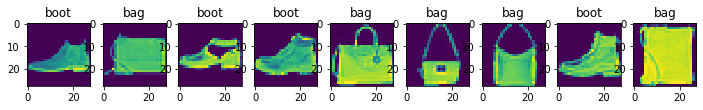

In [64]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(class_nameB[y_pred_B[i]])
    

## Exercise 5
Try the classification of the fashion mnist data set using the following optimizers.

In [65]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [66]:
optimizer1 = keras.optimizers.SGD(lr=0.001, momentum=0.9)

In [67]:
optimizer2 = keras.optimizers.SGD(lr=0.001, momentum=0.9, nesterov=True)

In [68]:
optimizer3 = keras.optimizers.RMSprop(lr=0.001, rho=0.9)

In [69]:
optimizer4 = keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999)

In [70]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer1, metrics=["accuracy"])

In [71]:
n_epochs = 10
history1 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.4886 - accuracy: 0.8307 - val_loss: 0.4116 - val_accuracy: 0.8532
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.3776 - accuracy: 0.8657 - val_loss: 0.3708 - val_accuracy: 0.8680
Epoch 3/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.3435 - accuracy: 0.8784 - val_loss: 0.3674 - val_accuracy: 0.8702
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.3215 - accuracy: 0.8856 - val_loss: 0.3503 - val_accuracy: 0.8732
Epoch 5/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3029 - accuracy: 0.8916 - val_loss: 0.3508 - val_accuracy: 0.8736
Epoch 6/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.2880 - accuracy: 0.8966 - val_loss: 0.3423 - val_accuracy: 0.8796
Epoch 7/10
55000/55000 [==============================] -

In [72]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [73]:
history4 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.4857 - accuracy: 0.8331 - val_loss: 0.3950 - val_accuracy: 0.8648
Epoch 2/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3539 - accuracy: 0.8706 - val_loss: 0.3503 - val_accuracy: 0.8726
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3119 - accuracy: 0.8854 - val_loss: 0.3527 - val_accuracy: 0.8730
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2874 - accuracy: 0.8929 - val_loss: 0.3488 - val_accuracy: 0.8826
Epoch 5/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2660 - accuracy: 0.9002 - val_loss: 0.3292 - val_accuracy: 0.8836
Epoch 6/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2474 - accuracy: 0.9083 - val_loss: 0.3630 - val_accuracy: 0.8844
Epoch 7/10
55000/55000 [==============================] -

In [74]:
history.params['metrics']

['loss', 'accuracy', 'val_loss', 'val_accuracy']

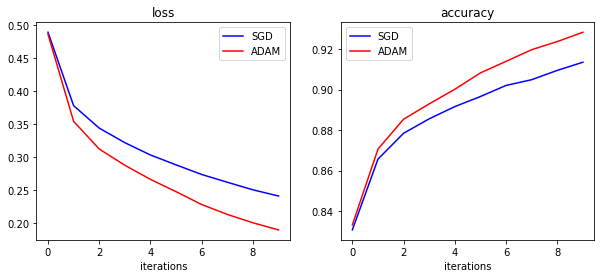

In [75]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history1,history4,'SGD','ADAM')

## Exercise 7: Learning Rate
Use the exponential rate decay defined below and compare with the previous result.\
We define a function whose job is to define another function. We do this nesting because of the parameters.

In [76]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.001, s=20)

(2, 10)


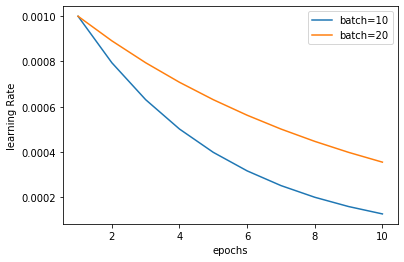

In [77]:
lr0=0.001
yy=np.zeros((2,10))
print(yy.shape)
s=[10,20]
for j in (0,1):
    exponential_decay_fn = exponential_decay(lr0,s[j])
    for i in range(10):
        yy[j,i]=(exponential_decay_fn(i))

ii=np.arange(1,11)
plt.plot(ii,yy[0,:],label='batch=10');
plt.plot(ii,yy[1,:],label='batch=20');
plt.xlabel('epochs');plt.ylabel('learning Rate')
plt.legend();


In [78]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [79]:
exponential_decay_fn = exponential_decay(lr0=0.001, s=20)

In [80]:
lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history4b = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[lr_scheduler])

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.4983 - accuracy: 0.8385 - val_loss: 0.3897 - val_accuracy: 0.8596
Epoch 2/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3274 - accuracy: 0.8772 - val_loss: 0.3611 - val_accuracy: 0.8674
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2845 - accuracy: 0.8941 - val_loss: 0.3222 - val_accuracy: 0.8800
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2530 - accuracy: 0.9040 - val_loss: 0.3153 - val_accuracy: 0.8866
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.2240 - accuracy: 0.9154 - val_loss: 0.3114 - val_accuracy: 0.8904
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.1998 - accuracy: 0.9241 - val_loss: 0.3399 - val_accuracy: 0.8866
Epoch 7/10
55000/55000 [==============================] -

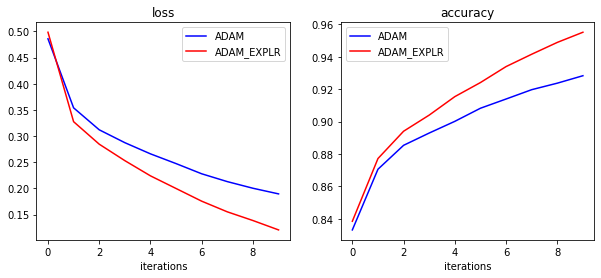

In [81]:
plot_history(history4,history4b,'ADAM','ADAM_EXPLR')

## Exercise 8: Regularization
Modify the previous network using l2 and l1 regularizations and compare with the previous result. Also compare with Dropout.

In [82]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [83]:
history5 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.4316 - accuracy: 0.8505 - val_loss: 0.3647 - val_accuracy: 0.8760
Epoch 2/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3007 - accuracy: 0.8892 - val_loss: 0.3211 - val_accuracy: 0.8876
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2618 - accuracy: 0.9035 - val_loss: 0.3188 - val_accuracy: 0.8874
Epoch 4/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.2349 - accuracy: 0.9119 - val_loss: 0.3175 - val_accuracy: 0.8832
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.2119 - accuracy: 0.9213 - val_loss: 0.3202 - val_accuracy: 0.8924
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.1941 - accuracy: 0.9277 - val_loss: 0.3189 - val_accuracy: 0.8912
Epoch 7/10
55000/55000 [==============================] -

In [84]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l2(0.001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [85]:
history5b = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 75us/sample - loss: 0.9764 - accuracy: 0.8489 - val_loss: 0.7301 - val_accuracy: 0.8726
Epoch 2/10
55000/55000 [==============================] - 3s 62us/sample - loss: 0.6200 - accuracy: 0.8773 - val_loss: 0.5633 - val_accuracy: 0.8740
Epoch 3/10
55000/55000 [==============================] - 3s 62us/sample - loss: 0.5077 - accuracy: 0.8828 - val_loss: 0.5083 - val_accuracy: 0.8760
Epoch 4/10
55000/55000 [==============================] - 3s 62us/sample - loss: 0.4607 - accuracy: 0.8849 - val_loss: 0.4691 - val_accuracy: 0.8772
Epoch 5/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4354 - accuracy: 0.8866 - val_loss: 0.4493 - val_accuracy: 0.8798
Epoch 6/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4195 - accuracy: 0.8890 - val_loss: 0.4406 - val_accuracy: 0.8810
Epoch 7/10
55000/55000 [==============================] -

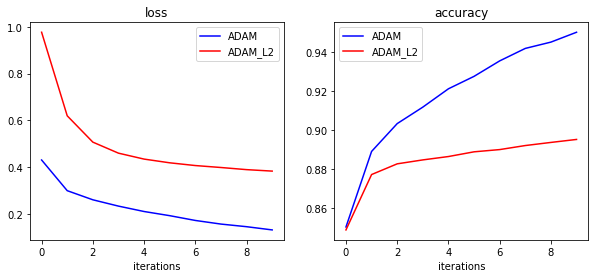

In [86]:
plot_history(history5,history5b,'ADAM','ADAM_L2')

In [87]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l1(0.0001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [88]:
history5c = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 72us/sample - loss: 1.3342 - accuracy: 0.8493 - val_loss: 1.0492 - val_accuracy: 0.8718
Epoch 2/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.8888 - accuracy: 0.8764 - val_loss: 0.7988 - val_accuracy: 0.8704
Epoch 3/10
55000/55000 [==============================] - 3s 64us/sample - loss: 0.7083 - accuracy: 0.8811 - val_loss: 0.6892 - val_accuracy: 0.8736
Epoch 4/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.6203 - accuracy: 0.8810 - val_loss: 0.6047 - val_accuracy: 0.8750
Epoch 5/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.5607 - accuracy: 0.8838 - val_loss: 0.5588 - val_accuracy: 0.8780
Epoch 6/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.5182 - accuracy: 0.8863 - val_loss: 0.5234 - val_accuracy: 0.8784
Epoch 7/10
55000/55000 [==============================] -

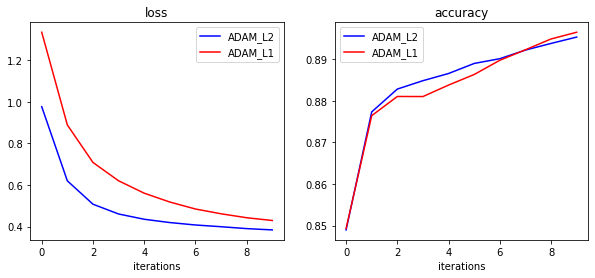

In [89]:
plot_history(history5b,history5c,'ADAM_L2','ADAM_L1')

### comparing with Dropout

In [90]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [91]:
history5d = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 74us/sample - loss: 0.5627 - accuracy: 0.8093 - val_loss: 0.3816 - val_accuracy: 0.8702
Epoch 2/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.4166 - accuracy: 0.8488 - val_loss: 0.3368 - val_accuracy: 0.8790
Epoch 3/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.3812 - accuracy: 0.8595 - val_loss: 0.3245 - val_accuracy: 0.8804
Epoch 4/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.3584 - accuracy: 0.8674 - val_loss: 0.3135 - val_accuracy: 0.8834
Epoch 5/10
55000/55000 [==============================] - 3s 64us/sample - loss: 0.3435 - accuracy: 0.8725 - val_loss: 0.3194 - val_accuracy: 0.8778
Epoch 6/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.3317 - accuracy: 0.8763 - val_loss: 0.3093 - val_accuracy: 0.8890
Epoch 7/10
55000/55000 [==============================] -

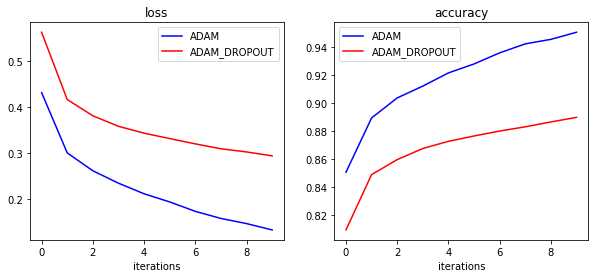

In [92]:
plot_history(history5,history5d,'ADAM','ADAM_DROPOUT')